In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [21]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean0 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_2/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean2 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_3/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean3 = np.mean(si_array, axis=0)

In [22]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_0_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean0 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_2_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean2 = np.mean(si_array, axis=0)

si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_3_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean3 = np.mean(si_array, axis=0)

In [23]:
mcmc_3 = np.load("mcmc_results_3/avg_wd_mcmc.npy")
mcmc_0 = np.load("mcmc_results_0/avg_wd_mcmc.npy")
mcmc_2 = np.load("mcmc_results_2/avg_wd_mcmc.npy")
sample_no_list = np.load("sample_no_list.npy").tolist()

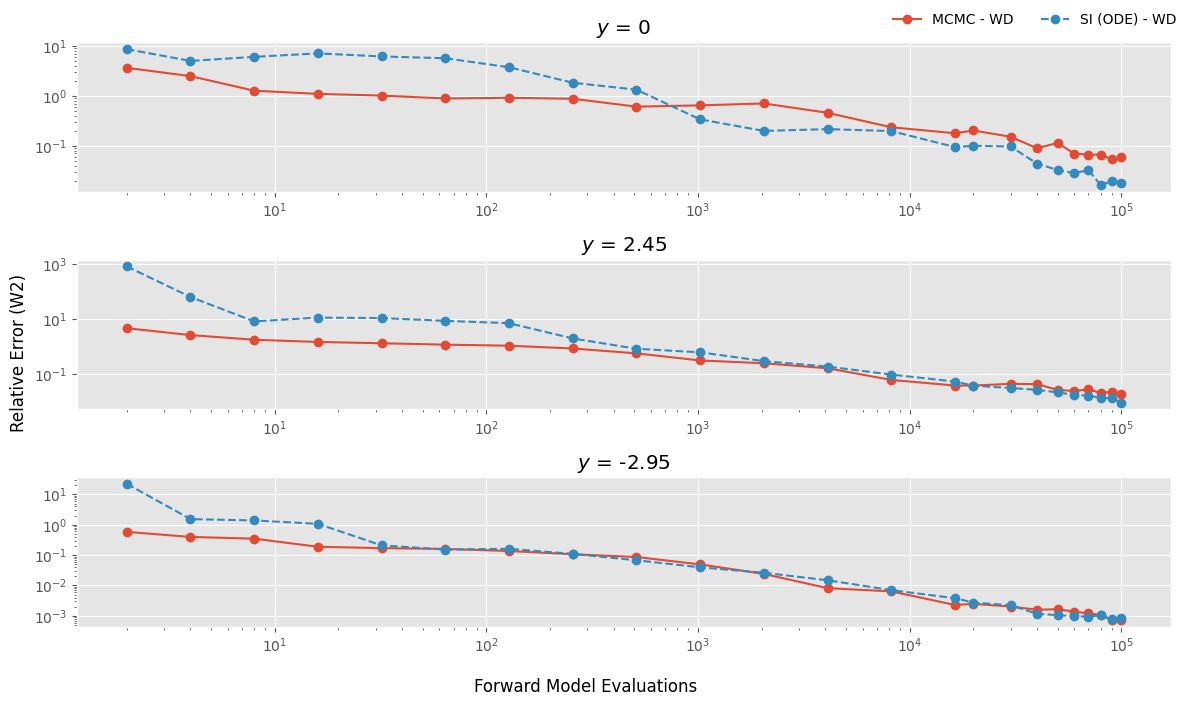

In [31]:
fig, ax = plt.subplots(3, 1, figsize=(12,7))

ax[0].plot(sample_no_list, mcmc_0, marker="o", label="MCMC - WD")
ax[0].plot(sample_no_list, ode_mean0, marker="o", linestyle="dashed", label="SI (ODE) - WD")
# ax[0].plot(sample_no_list, sde_mean0, marker="o", linestyle="dotted", label="SI (SDE) - WD")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y$ = 0")

ax[1].plot(sample_no_list, mcmc_2, marker="o")
ax[1].plot(sample_no_list, ode_mean2, marker="o", linestyle="dashed")
# ax[1].plot(sample_no_list, sde_mean2, marker="o", linestyle="dotted")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y$ = 2.45")

ax[2].plot(sample_no_list, mcmc_3, marker="o")
ax[2].plot(sample_no_list, ode_mean3, marker="o", linestyle="dashed")
# ax[2].plot(sample_no_list, sde_mean3, marker="o", linestyle="dotted")
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y$ = -2.95")

fig.supylabel("Relative Error (W2)")
fig.supxlabel("Forward Model Evaluations")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False
)

plt.tight_layout()